In [1]:
import subprocess
import sys

#### If running on ROOT casa image some packages necessary for opening our files and plotting are not installed

def install_package(package_name):
    # Install the package using subprocess to call pip
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

def import_packages():
    try:
        import mplhep  # Replace with the module name of the package
    except ImportError:
        print(f"{'mplhep'} not found. Installing...")
        install_package("mplhep")
        import mplhep  # Import again after installation
    try:
        import hist  # Replace with the module name of the package
    except ImportError:
        print(f"{'hist'} not found. Installing...")
        install_package("hist")
        import hist  # Import again after installation
    try:
        import coffea  # Replace with the module name of the package
    except ImportError:
        print(f"{'coffea'} not found. Installing...")
        install_package("coffea==0.7.22")
        import coffea  # Import again after installation
        
        
import_packages()

In [2]:
import hist
import pickle as pkl
# from unfold_utils.unfolderv3 import *
#import ipywidgets as widgets
#from IPython.display import display
from unfold_utils.draw_tools import * 
# from unfold_utils.integrate_and_rebin import *

Welcome to JupyROOT 6.26/04


In [3]:
%load_ext autoreload

%autoreload 2

In [4]:
import matplotlib.cm as cm
color_pt  = cm.tab10.colors 

In [5]:
groomed=True
if groomed:
    dijet_fname = "latest_pkl/dijet_unfold_outputs_g_tribins.pkl"
    trijet_fname = "latest_pkl/trijet_unfold_outputs_g.pkl"
    groom_str = "_g"
else:
    dijet_fname = "latest_pkl/dijet_unfold_outputs_u_tribins.pkl"
    trijet_fname = "latest_pkl/trijet_unfold_outputs_u.pkl"
    groom_str = "_u"
with open(dijet_fname, "rb") as f:
    output_dijet= pkl.load( f )   
with open(trijet_fname, "rb") as f:
    output_trijet= pkl.load( f )   

[0.0, 20.0, 40.0, 60.0, 80.0, 120.0, 160.0, 200.0, 300.0, 400.0, 500.0, 900.0, 1300.0]
[  10.   30.   50.   70.  100.  140.  180.  250.  350.  450.  700. 1100.]
5
Dijet
Check that sum of values  41931906.768075384  is same as integrate  41939787.03815068
Sum of hist vals after norming 1.0000000000000002
Mean for bin  0  and channel  Dijet   33.48286215426863
hist                        ┌─────────────────────────────────────────────────────┐
[-inf,    0) 0         │                                                     │
[   0,   20) 0.4995    │████████████████████████████████████████████████████ │
[  20,   40) 0.1615    │████████████████▉                                    │
[  40,   60) 0.1288    │█████████████▍                                       │
[  60,   80) 0.1136    │███████████▉                                         │
[  80,  120) 0.09199   │█████████▋                                           │
[ 120,  160) 0.004246  │▌                                                    │
[ 

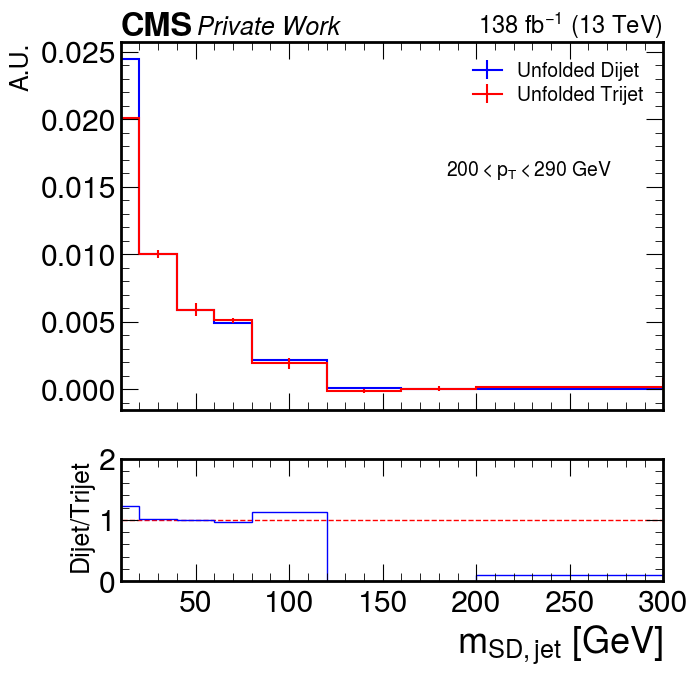

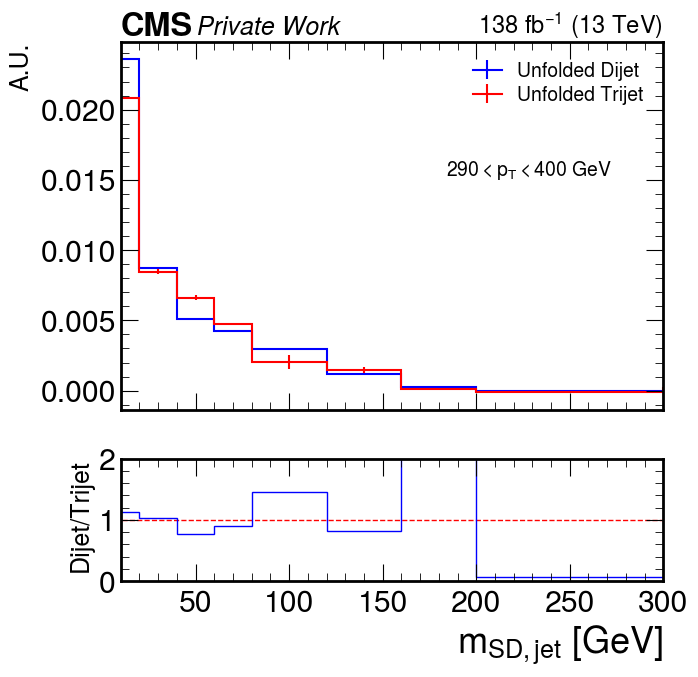

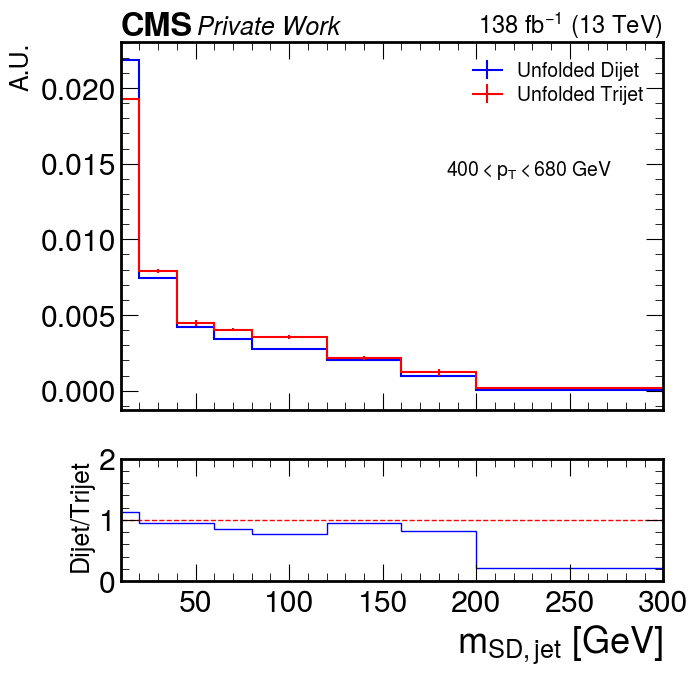

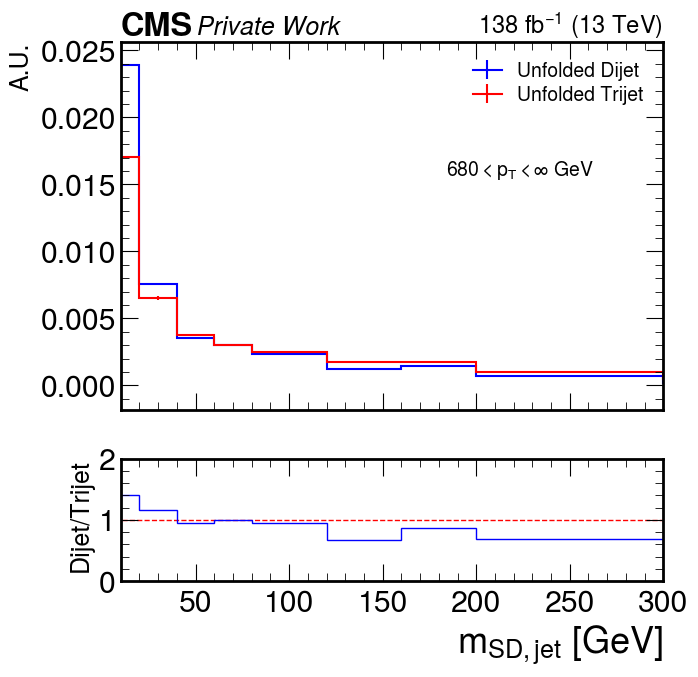

In [6]:
channels = ["Dijet", "Trijet"]
htrue = [output_trijet["pythia_truth"], output_trijet["pythia_truth"]]
ptedges = [bin[0] for bin in htrue[0].project("ptgen").axes[0]] + [htrue[0].project("ptgen").axes[0][-1][1]]
medges = [bin[0] for bin in htrue[0].project('mgen').axes[0]]+ [htrue[0].project('mgen').axes[0][-1][1]]
widths = htrue[0].project("mgen").axes[0].widths
print(medges)
mcenters = 0.5 * (np.array(medges)[:-1] + np.array(medges)[1:])
print(mcenters) 
sys_errs = [output_dijet["total_sys"], output_trijet["total_sys"]]
o_pt_binned = [output_dijet["unfolded_result"], output_trijet["unfolded_result"]]
stat_errs = [output_dijet["stat_unc"], output_trijet["stat_unc"]]
norm=True
print(len(ptedges))
for ipt in range(len(ptedges)-1):
        #### set up figure   
    fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(7,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
    for i in range(len(channels)):
        channel = channels[i]
        if channel == "Trijet":
            tot_error_opts = {
                    'label': 'Tot. Unc.'+channel,
                    'facecolor': 'pink',
                    'linewidth': 0
                }
            stat_error_opts = {
                            'label': 'Stat. Unc.',
                'facecolor': 'palevioletred',
                'linewidth': 0
            }
        else:
            tot_error_opts = {
                            'label': 'Tot. Unc.'+channel,
                    'facecolor': 'powderblue',
                    'linewidth': 0
                }
            stat_error_opts = {
                            'label': 'Stat. Unc.',
                    'facecolor': 'cadetblue',
                    'linewidth': 0
                }
        print(channels[i])
        if i == 0:
            color = "Blue"
        else:
            color = "Red"
        if ipt==0:
            medge_upper = -4
        sysErr =sys_errs[i][ipt]
        oHistVals = o_pt_binned[i][ipt]
        oHistErr = stat_errs[i][ipt]
        totErr = (sysErr**2+oHistErr**2)**0.5
        hist = htrue[i][{'ptgen':ipt, 'syst':"nominal"}].project("mgen")
        if norm:
            print("Check that sum of values ", np.nansum(hist.values())," is same as integrate ", hist.integrate("mgen").value)
            hist = hist*1.0/hist.integrate("mgen").value
            oVals_sum = np.nansum(oHistVals)
            oHistVals = oHistVals*1.0/oVals_sum
            oHistErr = oHistErr/oVals_sum
            totErr = totErr/oVals_sum
            
            print("Sum of hist vals after norming", np.nansum(oHistVals))
            print("Mean for bin ", ipt, " and channel ", channel, " ", np.sum(oHistVals*mcenters)) 
        #### oHistVal == Data; hist.values == MC
        #oHistVals = np.array([o.GetBinContent(im+(ipt*(len(medges)-1))) for im in range(len(medges)-1)])
        print("hist", hist)
        # ax.stairs(values=(oHistVals+totErr)/widths, edges = medges, baseline= (oHistVals-totErr)/widths,                             
        #         fill=True,                                                                                                                                  
        #         **tot_error_opts,                         
        #     )
        hep.histplot(oHistVals, medges, stack=False, histtype='step', yerr = oHistErr,
                 ax=ax, color = color, binwnorm=True,
                 label="Unfolded "+channels[i])
        # ax.stairs(values=(oHistVals+oHistErr)/widths, edges = medges, baseline= (oHistVals-oHistErr)/widths,
        #         fill=True,
        #         **stat_error_opts,
        #     )

        leg = ax.legend(loc='upper right', fontsize=14, labelspacing=0.25)
        ax.set_xlim(10,300)
        rax.set_ylim(0,2)
        ax.set_ylabel("A.U.", fontsize=18)
        leg.set_visible(True)
    hep.cms.label("Private Work", lumi=138, com=13, data = True, loc=0, ax=ax, fontsize=18);
    ratio = np.divide(o_pt_binned[0][ipt],o_pt_binned[1][ipt],
                      out=np.empty(np.array(hist.project("mgen").values()).shape).fill(1),
                      where= oHistVals!=0,)
    hep.histplot(np.ones_like(ratio), medges, histtype='step', ax=rax, linestyle ="--", color = 'Red', linewidth=1)
    hep.histplot(ratio, medges, histtype='step',color = 'Blue', linewidth=1, yerr = np.zeros_like(ratio))#,
    if ipt != len(ptedges)-2:
        ax.text(0.60, 0.62, str(int(ptedges[ipt]))+r"$<p_{T}<$" +str(int(ptedges[ipt+1])) + " GeV",verticalalignment='bottom', horizontalalignment='left',
                transform=ax.transAxes, color='Black', fontsize=14)
    else:         
        ax.text(0.60, 0.62, str(int(ptedges[ipt]))+r"$<p_{T}<\infty$ GeV",verticalalignment='bottom', horizontalalignment='left',
                transform=ax.transAxes, color='Black', fontsize=14)
    rax.set_ylabel("Dijet/Trijet", fontsize=18)
    ax.set_xlabel("")       # remove x-axis label on the top panel
    if groomed:
        rax.set_xlabel(r"$m_{SD,jet}$ [GeV]")
    else:
        rax.set_xlabel(r"$m_{jet}$ [GeV]")  # show x-axis label here
    plt.savefig(f"../plots/unfolding/unfolded_comparison{groom_str}_{ptedges[i]}_{ptedges[i+1]}.pdf", bbox_inches="tight")